In [ ]:
import numpy as np
import pandas as pd
from glob import glob
from matplotlib import pyplot as plt
import seaborn as sns
import pickle as pkl
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from one.api import ONE
from sklearn.decomposition import PCA
from dPCA import dPCA
from sklearn.metrics import euclidean_distances
from scipy import stats
from manifold.pseudosession_manifolds import analyze_stitched_manifold

In [ ]:
import warnings

warnings.filterwarnings("ignore")

In [ ]:
import plotly.io as pio

pio.renderers.default = "notebook"

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
# def get_region_stats():
#     one = ONE()
#     units_df = bwm_units(one)
#     neuron_counts = units_df.groupby(["Beryl", "eid"]).size().reset_index(name="neuron_count")
#     valid_pairings = neuron_counts[neuron_counts["neuron_count"] >= 5]
#     # print(valid_pairings)  # atleast 10 neurons
#     final_counts = (
#         valid_pairings.groupby("Beryl")["eid"]
#         .nunique()
#         .reset_index(name="valid_eid_count")
#         .sort_values(by="valid_eid_count", ascending=False)
#     )
#     # print(final_counts)
#     regions_of_interest = final_counts[final_counts["valid_eid_count"] >= 20]["Beryl"].values
#     region_totals = units_df.groupby("Beryl").size()
#     valid_regions = region_totals[region_totals >= 20].index
#     df_valid = units_df[units_df["Beryl"].isin(valid_regions)]

#     final_table = (
#         df_valid.groupby("Beryl")["eid"]
#         .agg(
#             total_neurons="size",
#             unique_eid_count="nunique",
#             eids_list=lambda x: list(x.unique()),
#         )
#         .reset_index()
#         .sort_values(by="total_neurons", ascending=False)
#     )
#     # final_table[final_table["unique_eid_count"] >= 10]["Beryl"].values
#     return final_table, final_counts

In [ ]:
# files = np.sort(glob("../data/generated/manifold/true_results/*.pkl"))
# pseudo_files = np.sort(glob("../data/generated/manifold/pseudosession/*.pkl"))

In [ ]:
# def plot_trajectories(traj_A, traj_B,region):
#     import plotly.graph_objects as go

#     trace_A = go.Scatter3d(
#         x=traj_A[:, 0],
#         y=traj_A[:, 1],
#         z=traj_A[:, 2],
#         mode="lines+markers",
#         line=dict(color="blue", width=4),
#         marker=dict(
#             size=[8] + [2] * (len(traj_A) - 1), color="blue"
#         ),  # Makes the first dot bigger
#         name="Correct",
#     )

#     trace_B = go.Scatter3d(
#         x=traj_B[:, 0],
#         y=traj_B[:, 1],
#         z=traj_B[:, 2],
#         mode="lines+markers",
#         line=dict(color="red", width=4),
#         marker=dict(size=[8] + [2] * (len(traj_B) - 1), color="red"),  
#         name="Incorrect",
#     )

#     fig = go.Figure(data=[trace_A, trace_B])

#     fig.update_layout(
#         title=f"{region}",
#         scene=dict(xaxis_title="PC 1", yaxis_title="PC 2", zaxis_title="PC 3"),
#         width=400,
#         height=400,
#     )
#     fig.show()

In [ ]:
# def get_trajectory_data(data, unstiched=True):

#     if unstiched:
#         stiched_session = []
#         for k in data.keys():
#             stiched_session.append(data[k])
#         stiched_session = np.concatenate(stiched_session)
#     else:
#         stiched_session = data
    
#     pca = PCA(n_components=3)
#     pca_session = pca.fit_transform(stiched_session.T)
#     # print(pca_session.shape)
#     n_timepoints = 50
#     cond_A_data = pca_session[0:n_timepoints,:]
#     cond_B_data = pca_session[n_timepoints:,:]

#     return  pca.explained_variance_ratio_, stiched_session[:,0:50], stiched_session[:, 50:], stiched_session.shape


In [ ]:
# def get_trajectory_data_plot(data,region=""):

    
#     stiched_session = []
#     for k in data.keys():
#         stiched_session.append(data[k])
#     stiched_session = np.concatenate(stiched_session)
     
#     pca = PCA(n_components=3)
#     pca_session = pca.fit_transform(stiched_session.T)
#     # print(pca_session.shape)
#     n_timepoints = 50
#     cond_A_data = pca_session[0:n_timepoints,:]
#     cond_B_data = pca_session[n_timepoints:,:]
#     plot_trajectories(cond_A_data, cond_B_data,region)


In [ ]:
# def compute_participation_ratio(trajectory):
#     cov_matrix = np.cov(trajectory, bias=True)
    
#     trace_cov = np.trace(cov_matrix)
#     trace_cov_sq = np.trace(np.dot(cov_matrix, cov_matrix))
    
#     if trace_cov_sq == 0:
#         return 0.0
        
#     return (trace_cov ** 2) / trace_cov_sq

In [ ]:
# def transpose_and_stitch_fast(data):
#     stiched_session = []
#     for k in data.keys():
#         stiched_session.append(data[k])

#     n_pseudosessions = len(stiched_session[0])
    
#     return np.asarray([
#         np.vstack([session_data[p] for session_data in stiched_session]) 
#         for p in range(n_pseudosessions)
#     ])

In [ ]:
from scipy.stats import zscore

In [ ]:
# def analyze_full_space_manifold(balanced_supersession, n_timepoints=50):
#     """

#     balanced_supersession: shape (N_neurons, 100)
#     """
#     # balanced_supersession = zscore(balanced_supersession, axis=1)
#     # balanced_supersession = np.nan_to_num(balanced_supersession, nan=0.0)
    
#     cond_correct = balanced_supersession[:, :n_timepoints]   # Shape: (N, 50)
#     cond_incorrect = balanced_supersession[:, n_timepoints:] # Shape: (N, 50)


#     len_correct = np.sum(np.linalg.norm(np.diff(cond_correct, axis=1), axis=0))
#     len_incorrect = np.sum(np.linalg.norm(np.diff(cond_incorrect, axis=1), axis=0))
#     path_length_diff = len_incorrect - len_correct 


#     steps_correct = np.abs(np.diff(cond_correct, axis=1))
#     steps_incorrect = np.abs(np.diff(cond_incorrect, axis=1))
    

#     dist_neuron_correct = np.sum(steps_correct, axis=1)
#     dist_neuron_incorrect = np.sum(steps_incorrect, axis=1)
    
#     dist_diff = dist_neuron_incorrect - dist_neuron_correct

    
#     return  path_length_diff, dist_diff

In [ ]:
# from statsmodels.stats.multitest import multipletests

In [ ]:
# def get_stiched_supersession(data):
#     stiched_session_super = []
#     for k in data.keys():
#         stiched_session_super.append(data[k])
#     stiched_session_super = np.concatenate(stiched_session_super)
#     return stiched_session_super

In [ ]:
files = glob('../data/generated/manifold/true_results_congruence/*.pkl')

In [ ]:
rnames = []
for idx in range(len(files)):
    fname = files[idx]
    rname = fname.rsplit(".pkl")[0].rsplit("_")[-1]
    rnames.append(rname)


In [ ]:
# region_results_path = {}
# region_results_neuron = {}

# for idx in range(len(files)):
#     fname = files[idx]
#     fname_pseudo = pseudo_files[idx]
#     rname = fname.rsplit(".pkl")[0].rsplit("_")[-1]

    
#     with open(fname, "rb") as f:
#         true_data = pkl.load(f)
#     with open(fname_pseudo, "rb") as f:
#         pseudo_data = pkl.load(f)

#     stiched_session_true = get_stiched_supersession(true_data)
#     stacked_pseudo = transpose_and_stitch_fast(pseudo_data)

    
#     true_path_length_diff, true_dist_diff_array = analyze_full_space_manifold(stiched_session_true)
    
    
#     true_mean_dist_diff = np.mean(true_dist_diff_array)

    
#     null_path_diffs = []
#     null_mean_dist_diffs = []
#     all_pseudo_dist_arrays = [] 

#     for pseudo_n in range(len(stacked_pseudo)): 
#         pseudo_path_diff, pseudo_dist_diff_array = analyze_full_space_manifold(stacked_pseudo[pseudo_n])
        
#         null_path_diffs.append(pseudo_path_diff)
#         null_mean_dist_diffs.append(np.mean(pseudo_dist_diff_array))
#         all_pseudo_dist_arrays.append(pseudo_dist_diff_array)

    
#     region_results_path[rname] = {
#         "true_diff": true_path_length_diff,
#         "null_diffs": null_path_diffs
#     }
    
#     region_results_neuron[rname] = {
#         "true_diff": true_mean_dist_diff,
#         "null_diffs": null_mean_dist_diffs
#     }

    
#     fig, ax = plt.subplots(figsize=(5,5))
    
    
#     sns.kdeplot(true_dist_diff_array, color='blue', label='True', ax=ax)

#     for i in range(5): 
#         sns.kdeplot(all_pseudo_dist_arrays[i], color='red', alpha=0.3, ax=ax)
        
#     ax.set_title(f'{rname} - Single Neuron Distance Diffs')
#     ax.legend()
#     plt.show()

In [ ]:
# def compute_significance_and_fdr(region_results, alpha=0.05, tail="greater"):
#     """
#     Computes permutation p-values and applies FDR correction across all regions.
    
#     """
#     regions = list(region_results.keys())
#     raw_p_values = []
    
    
#     for region in regions:
#         true_diff = region_results[region]["true_diff"]
#         null_diffs = np.array(region_results[region]["null_diffs"])
#         n_pseudos = len(null_diffs)
        
#         if tail == "two-sided":
#             n_extreme = np.sum(np.abs(null_diffs) >= np.abs(true_diff))
#         elif tail == "greater":
#             n_extreme = np.sum(null_diffs >= true_diff)
#         elif tail == "less":
#             n_extreme = np.sum(null_diffs <= true_diff)
            
#         p_val = (n_extreme + 1) / (n_pseudos + 1)
#         raw_p_values.append(p_val)
        
#     reject_mask, fdr_p_values, _, _ = multipletests(
#         raw_p_values, alpha=alpha, method='fdr_bh'
#     )
    
    
#     final_stats = {}
#     for i, region in enumerate(regions):
#         final_stats[region] = {
#             "p_raw": raw_p_values[i],
#             "p_fdr": fdr_p_values[i],
#             "is_significant": reject_mask[i]
#         }
        
#     return final_stats

In [ ]:

# for r in rnames:
#     sig_path = compute_significance_and_fdr(region_results_path, alpha=0.05, tail="two-sided")
#     sig_neuron = compute_significance_and_fdr(region_results_neuron, alpha=0.05, tail="two-sided")
#     print(f"{r} Path Length Significant? {sig_path[r]['is_significant']}")
#     print(f"{r} Neuron Volatility Significant? {sig_neuron[r]['is_significant']}")

In [ ]:
def plot_trajectories_matplotlib(traj_A, traj_B, region):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(projection='3d')

    ax.plot(traj_A[:, 0], traj_A[:, 1], traj_A[:, 2], 
            color='blue', label='Correct', linewidth=1.5, marker='o', markersize=3)
    
    ax.plot(traj_B[:, 0], traj_B[:, 1], traj_B[:, 2], 
            color='red', label='Incorrect', linewidth=1.5, marker='o', markersize=3)


    ax.scatter(*traj_A[0, :], color='blue', s=80, edgecolor='black', zorder=5)
    ax.scatter(*traj_B[0, :], color='red', s=80, edgecolor='black', zorder=5)

    ax.scatter(*traj_A[-1, :], color='blue', s=80, edgecolor='black', zorder=5,marker='*')
    ax.scatter(*traj_B[-1, :], color='red', s=80, edgecolor='black', zorder=5,marker='*')


    ax.set_title(f"{region}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("PC 3")
    ax.legend()
    
    plt.tight_layout()
    plt.show()

In [ ]:


def plot_trajectories_multiple(traj_A, traj_B, traj_C, traj_D, region):
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(projection='3d')

    conditions = [
        (traj_A, 'blue',   'Incongruent correct'),
        (traj_B, 'red',    'Incongruent incorrect'),
        (traj_C, 'green',  'Congruent correct'),
        (traj_D, 'purple', 'Congruent incorrect')
    ]

    for traj, color, label in conditions:

        ax.plot(traj[:, 0], traj[:, 1], traj[:, 2], 
                color=color, label=label, linewidth=1.5, marker='o', markersize=3)
        ax.scatter(*traj[0, :], color=color, s=80, edgecolor='black', zorder=5)
        ax.scatter(*traj[-1, :], color=color, s=80, edgecolor='black', zorder=5, marker='*')


    ax.set_title(f"{region}")
    ax.set_xlabel("PC 1")
    ax.set_ylabel("PC 2")
    ax.set_zlabel("PC 3")
    ax.legend()
    
    plt.tight_layout()
    plt.show()

In [44]:
def get_trajectory_data_plot_matplotlib(data,region=""):

    
    stiched_session = []
    for k in data.keys():
        stiched_session.append(data[k])
    stiched_session = np.concatenate(stiched_session)
     
    pca = PCA(n_components=3)
    pca_session = pca.fit_transform(stiched_session.T)
    # print(pca_session.shape)
    n_timepoints = 50
    n_conditions = 4
    cond_A_data = pca_session[0:50,:]
    cond_B_data = pca_session[50:100,:]
    cond_C_data = pca_session[100:150,:]
    cond_D_data = pca_session[150:,:]
    # print(f'{region}: {np.sum(pca.explained_variance_ratio_)}')

#     conditions = {
#     label: pca_session[i * n_timepoints : (i + 1) * n_timepoints, :]
#     for i, label in enumerate(labels)
# }
    # plot_trajectories_multiple(cond_A_data, cond_B_data, cond_C_data, cond_D_data, region)
    return np.sum(pca.explained_variance_ratio_), stiched_session.shape[0]


In [45]:
q = []
regions = []
for idx in range(len(files)):
    fname = files[idx]
    rname = fname.rsplit(".pkl")[0].rsplit("_")[-1]

    
    with open(fname, "rb") as f:
        true_data = pkl.load(f)
    
    x,y = get_trajectory_data_plot_matplotlib(true_data, rname)
    q.append([x,y])
    regions.append(rname)

In [46]:
q = np.asarray(q)

In [47]:
q.shape

(30, 2)

Text(0.5, 1.0, 'Neuron count')

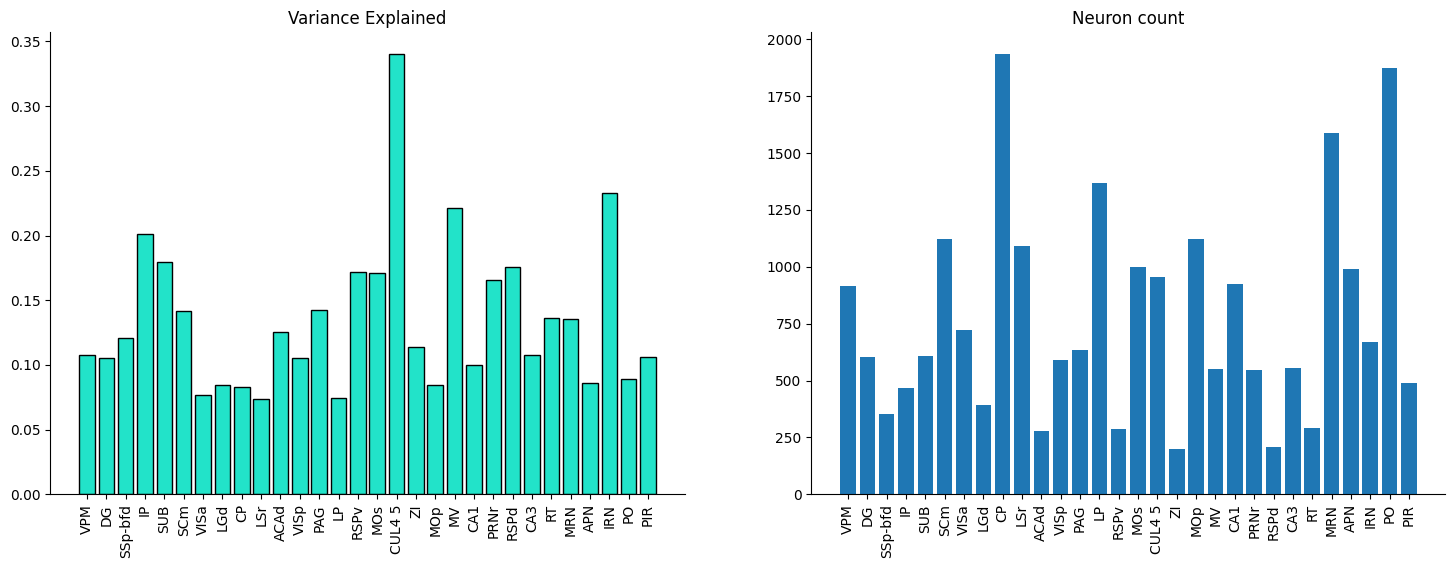

In [55]:
fig, ax = plt.subplots(figsize=(18,6), ncols=2)
ax[0].bar(np.arange(len(q)),q[:, 0], edgecolor='k', color="#22e3c9")
ax[0].set_xticks(np.arange(len(q)),regions, rotation=90)
ax[0].set_title('Variance Explained')
sns.despine()

ax[1].bar(np.arange(len(q)),q[:, 1])
ax[1].set_xticks(np.arange(len(q)),regions, rotation=90)
ax[1].set_title('Neuron count')
